# Supply Chain Logistics — Exploratory Analysis

Exploration of the ML-ready delivery-delay dataset produced by the pipeline.

Run the pipeline first (see `docs/reproduction_guide.md`), then execute this
notebook top to bottom.

**Contents**
1. Load the ML-ready data
2. Target distribution (`is_delayed`, `delivery_delay`)
3. Carrier and route performance
4. Feature correlations with delay
5. Verify the train/test split is clean

In [1]:
import os
import sys

import pandas as pd
import polars as pl

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

ML_READY = os.path.join(PROJECT_ROOT, "data", "ml_ready")
PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

## 1. Load the ML-ready data

Read with Polars (fast scan of the Parquet) and keep a pandas copy for the
plotting helpers.

In [2]:
train_pl = pl.read_parquet(os.path.join(ML_READY, "train.parquet"))
test_pl = pl.read_parquet(os.path.join(ML_READY, "test.parquet"))

print(f"train: {train_pl.height:,} rows x {train_pl.width} cols")
print(f"test : {test_pl.height:,} rows x {test_pl.width} cols")

train = train_pl.to_pandas()
test = test_pl.to_pandas()
train.head()

train: 82,851 rows x 27 cols
test : 20,697 rows x 27 cols


,order_id,customer_id,order_date,quantity,unit_price,discount_rate,weight_kg,distance_km,promised_delivery_days,shipping_cost,shipping_cost_per_unit,route_efficiency_score,carrier_performance_score,seasonal_demand_index,warehouse_utilization,inventory_turnover,reorder_risk_score,carrier,shipping_mode,product_category,customer_segment,destination_region,distance_category,shipment_size_category,order_status,is_delayed,delivery_delay
0,ORD-187901,CUST-31901,2024-05-21,2,13.20,0.00,2.71,5525.1,7,87.82,43.910,0.0476,0.7372,1.0423,0.0500,0.2567,0.2572,UPS,Standard Class,Electronics,Consumer,Asia Pacific,Long-Haul,Medium,PENDING,1,5
1,ORD-123846,CUST-43846,2025-10-02,3,65.85,0.00,1.37,427.6,4,10.15,3.383,0.2078,0.6274,1.0103,0.0051,0.6016,0.4524,Local Courier Co,Second Class,Automotive,Home Office,North America,Local,Small,COMPLETE,0,0
2,ORD-170473,CUST-52473,2025-08-28,24,10.33,0.05,3.04,275.2,6,9.36,0.390,0.0847,0.7412,1.0044,0.0074,0.3641,0.1675,FedEx,Standard Class,Health & Beauty,Home Office,North America,Local,Large,COMPLETE,0,0
3,ORD-201316,CUST-45316,2024-08-13,1,71.32,0.15,1.83,13891.6,8,212.52,212.520,0.1698,0.7372,1.0082,0.0090,0.3014,0.3551,UPS,Standard Class,Office Supplies,Corporate,Asia Pacific,International,Small,COMPLETE,1,1
4,ORD-192315,CUST-36315,2024-05-01,3,32.74,0.15,3.63,442.2,4,12.40,4.133,0.1037,0.7106,1.0423,0.0100,0.3957,0.2768,DB Schenker,Second Class,Electronics,Home Office,North America,Local,Medium,COMPLETE,1,4


## 2. Target distribution

The pipeline emits both targets named in the brief: `is_delayed` (binary
classification) and `delivery_delay` in days (regression).

In [3]:
balance = train["is_delayed"].value_counts(normalize=True).sort_index()
print("is_delayed class balance (train):")
print(balance.rename({0: "on time", 1: "delayed"}).round(4))

print("\ndelivery_delay (days) describe:")
train["delivery_delay"].describe().round(3)

is_delayed class balance (train):
is_delayed
on time    0.7118
delayed    0.2882
Name: proportion, dtype: float64

delivery_delay (days) describe:


count    82851.000
mean         0.391
std          1.287
min         -1.000
25%          0.000
50%          0.000
75%          1.000
max         10.000
Name: delivery_delay, dtype: float64

Matplotlib is building the font cache; this may take a moment.


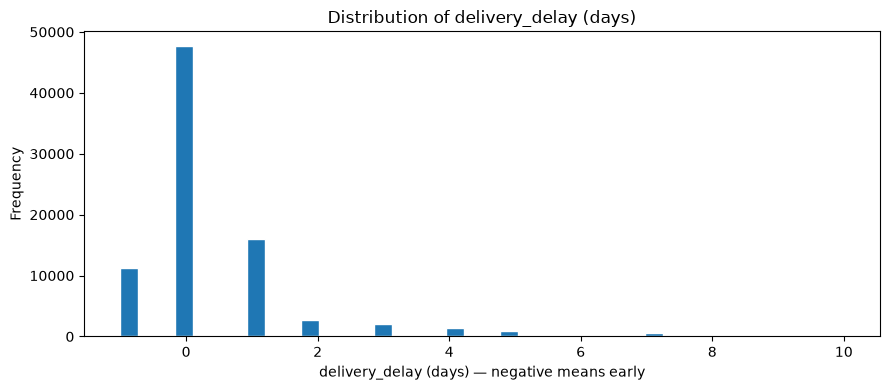

In [4]:
ax = train["delivery_delay"].plot(
    kind="hist", bins=40, figsize=(9, 4),
    title="Distribution of delivery_delay (days)", edgecolor="white",
)
ax.set_xlabel("delivery_delay (days) — negative means early")
ax.figure.tight_layout()

## 3. Carrier and route performance

Group-bys done in Polars to show the same aggregation the Spark stage
performs at scale.

In [5]:
carrier_perf = (
    train_pl
    .group_by("carrier")
    .agg([
        pl.len().alias("orders"),
        (1 - pl.col("is_delayed").mean()).round(4).alias("on_time_rate"),
        pl.col("delivery_delay").mean().round(3).alias("avg_delay_days"),
        pl.col("shipping_cost_per_unit").mean().round(2).alias("avg_cost_per_unit"),
    ])
    .sort("on_time_rate", descending=True)
)
carrier_perf

carrier,orders,on_time_rate,avg_delay_days,avg_cost_per_unit
str,u32,f64,f64,f64
"""DHL Express""",14719,0.7493,0.26,45.64
"""FedEx""",16624,0.7419,0.287,46.11
"""UPS""",16645,0.7388,0.308,45.3
"""DB Schenker""",12503,0.7107,0.4,45.88
"""Maersk Line""",9990,0.668,0.533,45.21
"""Local Courier Co""",12370,0.6268,0.671,45.26


In [6]:
by_distance = (
    train_pl
    .group_by("distance_category")
    .agg([
        pl.len().alias("orders"),
        pl.col("delivery_delay").mean().round(3).alias("avg_delay_days"),
        pl.col("route_efficiency_score").mean().round(3).alias("avg_route_efficiency"),
    ])
    .sort("avg_delay_days", descending=True)
)
by_distance

distance_category,orders,avg_delay_days,avg_route_efficiency
str,u32,f64,f64
"""Local""",33099,0.414,0.155
"""Long-Haul""",14733,0.393,0.107
"""Regional""",5540,0.393,0.038
"""International""",29479,0.363,0.201


## 4. Which features move with delay?

Numeric correlation against the regression target. Useful as a first pass at
feature selection before modelling.

In [7]:
numeric = train.select_dtypes("number").drop(columns=["is_delayed"], errors="ignore")
corr = (
    numeric.corr(numeric_only=True)["delivery_delay"]
    .drop(labels=["delivery_delay"], errors="ignore")
    .sort_values(key=abs, ascending=False)
)
corr.round(3).to_frame("corr_with_delivery_delay")

,corr_with_delivery_delay
route_efficiency_score,-0.227
carrier_performance_score,-0.112
reorder_risk_score,0.031
promised_delivery_days,-0.023
distance_km,-0.020
shipping_cost,-0.017
shipping_cost_per_unit,-0.014
seasonal_demand_index,0.008
weight_kg,0.004
warehouse_utilization,-0.004


## 5. Split sanity checks

The split is keyed on an md5 hash of `order_id`, so it must be stable and
leak-free. Both checks below should pass.

In [8]:
overlap = set(train["order_id"]) & set(test["order_id"])
print(f"order_id overlap between train and test: {len(overlap)}  (expected 0)")

test_share = len(test) / (len(train) + len(test))
print(f"test share: {test_share:.4f}  (target ~0.20)")

print("\nclass balance train vs test:")
pd.DataFrame({
    "train": train["is_delayed"].value_counts(normalize=True).sort_index().round(4),
    "test": test["is_delayed"].value_counts(normalize=True).sort_index().round(4),
})

order_id overlap between train and test: 0  (expected 0)
test share: 0.1999  (target ~0.20)

class balance train vs test:


,train,test
is_delayed,,
0,0.7118,0.7081
1,0.2882,0.2919
